In [2]:
using Pkg
Pkg.activate("../18337")
using Gridap, Gridap.Geometry, Gridap.Fields, GridapGmsh
using LinearAlgebra

  Activating project at `c:\Rena\MIT2\18.337\18337`


In [3]:
model = GmshDiscreteModel("CantileverBeam.msh")

Info    : Reading 'CantileverBeam.msh'...
Info    : 13 entities
Info    : 7589 nodes
Info    : 15178 elements
Info    : Done reading 'CantileverBeam.msh'


UnstructuredDiscreteModel()

In [5]:
# Define FE space
order = 1
reffe = ReferenceFE(lagrangian, VectorValue{2,Float64}, order)

V = TestFESpace(
    model,
    reffe;
    conformity = :H1,
    dirichlet_tags = ["Clamp", "ClampNodes"],
    dirichlet_masks = [(true, true), (true, true)]
)
u_D(x) = VectorValue(0.0, 0.0)

U = TrialFESpace(V, u_D)

TrialFESpace()

In [6]:
# Define integration over certain domains
degree = 2

Ω = Triangulation(model)
dΩ = Measure(Ω, degree)

Ω_d = Triangulation(model, tags = "Design")
dΩ_d = Measure(Ω_d, degree)

Γ_load = BoundaryTriangulation(model; tags = ["Load"])
dΓ_load = Measure(Γ_load, degree)

GenericMeasure()

In [7]:
# FE spaces for design parameters
p_reffe = ReferenceFE(lagrangian, Float64, 0)
Q = TestFESpace(Ω_d, p_reffe, vector_type = Vector{Float64})
P = Q
np = num_free_dofs(P) # Number of cells in design region (number of design parameters)

pf_reffe = ReferenceFE(lagrangian, Float64, 1)
Qf = TestFESpace(Ω_d, pf_reffe, vector_type = Vector{Float64})
Pf = Qf

fem_params = (; V, U, Q, P, Qf, Pf, np, Ω, dΩ, dΩ_d, dΓ_load)

(V = UnconstrainedFESpace(), U = TrialFESpace(), Q = UnconstrainedFESpace(), P = UnconstrainedFESpace(), Qf = UnconstrainedFESpace(), Pf = UnconstrainedFESpace(), np = 14776, Ω = BodyFittedTriangulation(), dΩ = GenericMeasure(), dΩ_d = GenericMeasure(), dΓ_load = GenericMeasure())

In [8]:
# PHYSICAL PARAMETERS
E0 = 2.5          # Young's modulus of solid material (GPa)
Emin = 1e-6       # small stiffness for "void" material
ν = 0.33          # Poisson's ratio
q_simp = 3        # SIMP penalization exponent
Vf = 0.4          # allowed volume fraction
L = 0.04          # beam length (m)
H = 0.01          # beam height (m)
t = 0.01          # thickness if using 2D plane stress as a physical plate/beam (m), not used if treating as a 2D plane strain problem
f_load = -1.0     # magnitude of downward load (N/m)
traction = VectorValue(0.0, f_load) # downward traction on right edge 
phys_params = (; E0, Emin, ν, q_simp, Vf, L, H, t, traction)

# PROBLEM PARAMETERS
r = 0.0005          # Helmholtz filter radius
β = 8                   # β∈[1,∞], threshold sharpness
η = 0.5                     # η∈[0,1], threshold center

0.5

In [9]:
a_f(r, u, v) = r^2 * (∇(v) ⋅ ∇(u))

function Filter(p0; r, fem_params) 
    ph = FEFunction(fem_params.P, p0)
    op = AffineFEOperator(fem_params.Pf, fem_params.Qf) do u, v
        ∫(a_f(r, u, v))fem_params.dΩ_d + ∫(v * u)fem_params.dΩ_d, ∫(v * ph)fem_params.dΩ_d
      end
    pfh = solve(op)
    return get_free_dof_values(pfh)
end

function Threshold(pfh; β, η)
    return ((tanh(β * η) + tanh(β * (pfh - η))) / (tanh(β * η) + tanh(β * (1.0 - η))))
end

Threshold (generic function with 1 method)

In [10]:
# Problem formulation
struct SIMP{PT} <: Function # New Julia function type for SIMP material model
    params::PT
end

function (s::SIMP)(ρ) # ρ is the design variable (density) at a point
    p = s.params.q_simp
    E0 = s.params.E0
    Emin = s.params.Emin
    return Emin + ρ^p * (E0 - Emin)
end

In [11]:
# Define elasticity tensors and stress-strain relationships
ε(u) = 0.5 * (∇(u) + ∇(u)')
λ(E, ν) = (E * ν) / ((1.0 + ν) * (1.0 - 2.0ν))
μ(E, ν) = E / (2.0 * (1.0 + ν))

const I2 = TensorValue(1.0, 0.0,
                       0.0, 1.0) # 2D identity tensor

function σ_from_E(u, E, poisson)
    lambda_val = λ(E, poisson)
    mu_val = μ(E, poisson)
    strain_u = ε(u)

    return lambda_val * tr(strain_u) * I2 +
           2.0 * mu_val * strain_u
end

function a_base_elastic(u, v; phys_params)
    Emin = phys_params.Emin
    ν = phys_params.ν

    return ε(v) ⊙ σ_from_E(u, Emin, ν)
end

function a_design_elastic(u, v, pth; phys_params)
    E0 = phys_params.E0
    Emin = phys_params.Emin
    ν = phys_params.ν
    q = phys_params.q_simp

    σ0 = σ_from_E(u, E0, ν)
    σmin = σ_from_E(u, Emin, ν)
    simp_pth = ((p -> p^q) ∘ pth)

    return (simp_pth) * (ε(v) ⊙ (σ0 - σmin))
end

function MatrixK(pth; phys_params, fem_params) # full stiffness matrix assembly through LU factorization
    K_mat = assemble_matrix(fem_params.U, fem_params.V) do u, v
        ∫(a_base_elastic(u, v; phys_params))fem_params.dΩ +
        ∫(a_design_elastic(u, v, pth; phys_params))fem_params.dΩ_d
    end

    return lu(K_mat)
end

MatrixK (generic function with 1 method)

In [12]:
# Initial forward solve
p0 = zeros(fem_params.np)  # Here we make p=0 everywhere just for illustration purpose
pf_vec = Filter(p0;r, fem_params)
pfh = FEFunction(fem_params.Pf, pf_vec)
pth = (pf -> Threshold(pf; β, η)) ∘ pfh
K_mat = MatrixK(pth; phys_params = phys_params, fem_params = fem_params)

F_vec = assemble_vector(fem_params.V) do v
    ∫(v ⋅ phys_params.traction)fem_params.dΓ_load
end

u_vec = K_mat \ F_vec
uh = FEFunction(fem_params.U, u_vec)

SingleFieldFEFunction():
 num_cells: 14776
 DomainStyle: ReferenceDomain()
 Triangulation: BodyFittedTriangulation()
 Triangulation id: 17042972116962151437

In [13]:
# Objective function (compliance)
function Compliance(u_vec, F_vec)
    return dot(F_vec, u_vec)
end

# Total volume of the design domain
function DesignVolume(; fem_params)
    return sum(∫(1.0)fem_params.dΩ_d)
end

# Physical volume fraction using thresholded density pth
function VolumeFraction(pth; fem_params)
    Vd = DesignVolume(fem_params=fem_params)
    return sum(∫(pth)fem_params.dΩ_d) / Vd
end

# Volume constraint: gV <= 0
function VolumeConstraint(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β=β, η=η)) ∘ pfh
    
    return VolumeFraction(pth; fem_params=fem_params) - phys_params.Vf
end

VolumeConstraint (generic function with 1 method)

### Optimization with Adjoint Method

In [14]:
using ChainRulesCore, Zygote
import ChainRulesCore: rrule
NO_FIELDS = ZeroTangent()

ZeroTangent()

In [15]:
# Some helper derivatives
Dptdpf(pf, β, η) = β * (1.0 - tanh(β * (pf - η))^2) / (tanh(β * η) + tanh(β * (1.0 - η)))

# Derivative of SIMP Young's Modulus w.r.t pf
function DEdpf(pf, phys_params, β, η)
    q = phys_params.q_simp
    E0 = phys_params.E0
    Emin = phys_params.Emin
    
    # Formula: dE/dpth * dpth/dpf
    dE_dpth = q * Threshold(pf; β=β, η=η)^(q - 1) * (E0 - Emin)
    return dE_dpth * Dptdpf(pf, β, η)
end

# Derivative of SIMP density factor w.r.t pf
function DSIMPdpf(pf, phys_params, β, η)
    q = phys_params.q_simp
    
    # Formula: d(pth^q)/dpth * dpth/dpf
    dSIMP_dpth = q * Threshold(pf; β=β, η=η)^(q - 1)
    return dSIMP_dpth * Dptdpf(pf, β, η)
end

# Derivative of the Elasticity Weak Form w.r.t pf
function DKdpf(u, v, pfh; phys_params, β, η)
    E0 = phys_params.E0
    Emin = phys_params.Emin
    ν = phys_params.ν
    
    # Base stress tensors
    σ0 = σ_from_E(u, E0, ν)
    σmin = σ_from_E(u, Emin, ν)
    
    # Map the SIMP derivative over the domain
    dSIMP_func = p -> DSIMPdpf(p, phys_params, β, η)
    
    return (dSIMP_func ∘ pfh) * (ε(v) ⊙ (σ0 - σmin))
end

# Compliance objective as a function of filtered density pf
function gf_pf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β = β, η = η)) ∘ pfh
    
    # Solve forward displacement
    K_mat = MatrixK(pth; phys_params = phys_params, fem_params = fem_params)

    F_vec = assemble_vector(fem_params.V) do v
        ∫(v ⋅ phys_params.traction)fem_params.dΓ_load
    end

    u_vec = K_mat \ F_vec
    
    # Compliance objective: g = Fᵀu
    return dot(F_vec, u_vec)
end

#### Adjoint Objective Derivative (`Dgfdpf`)
# This calculates the gradient of the compliance with respect to the filtered variables pf.

function Dgfdpf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β=β, η=η)) ∘ pfh
    
    # Solve forward displacement
    K_mat = MatrixK(pth; phys_params=phys_params, fem_params=fem_params)
    F_vec = assemble_vector(v -> ∫(v ⋅ phys_params.traction)fem_params.dΓ_load, fem_params.V)
    u_vec = K_mat \ F_vec
    uh = FEFunction(fem_params.U, u_vec)
    
    # Compliance is self-adjoint: adjoint field w = uh
    # Sensitivity = -∫ [ uh * (dK/dpf) * uh ] dΩ
    l_temp(dp) = ∫( -1.0 * DKdpf(uh, uh, pfh; phys_params=phys_params, β=β, η=η) * dp )fem_params.dΩ_d
    
    return assemble_vector(l_temp, fem_params.Qf)
end


#### Filter Adjoint (`Dgdp`)
# This propagates the gradient from the filtered space pf back to the design variables p.

function Dgdp(dgdpf; r, fem_params)
    # Assemble the Filter PDE matrix (Af)
    Af = assemble_matrix(fem_params.Pf, fem_params.Qf) do u, v
        ∫(a_f(r, u, v))fem_params.dΩ_d + ∫(v * u)fem_params.dΩ_d
    end
    
    # Adjoint solve for the filter (Af is symmetric)
    wvec = Af' \ dgdpf
    wh = FEFunction(fem_params.Pf, wvec)
    
    # Convert sensitivity back to the piece-wise constant space P
    return assemble_vector(dp -> ∫(wh * dp)fem_params.dΩ_d, fem_params.P)
end

Dgdp (generic function with 1 method)

In [16]:
### Custom adjoint rules
# Helmholtz filter forward and backward rules for AD
# Forward map: p -> pf
function pf_p0(p0; r, fem_params)
    pf_vec = Filter(p0; r = r, fem_params = fem_params)
    return pf_vec
end

# Custom reverse rule for p -> pf
function ChainRulesCore.rrule(::typeof(pf_p0), p0; r, fem_params)

    function pf_pullback(dgdpf)
        # dgdpf is ∂g/∂pf coming from later in the computational graph
        dgdpf_vec = unthunk(dgdpf)

        # Pull gradient back through the Helmholtz filter:
        # dg/dp = Mᵀ Af^{-T} dg/dpf
        dgdp = Dgdp(dgdpf_vec; r = r, fem_params = fem_params)

        return NoTangent(), dgdp
    end

    return pf_p0(p0; r = r, fem_params = fem_params), pf_pullback
end

# Custom reverse rule for pf -> compliance
function ChainRulesCore.rrule(::typeof(gf_pf), pf_vec; β, η, phys_params, fem_params)

    function gf_pullback(dgdg)
        # dgdg is the upstream scalar sensitivity.
        # Usually dgdg = 1.0 if this is the final scalar objective.
        dgdg_val = unthunk(dgdg)

        # Local derivative: dg/dpf
        dgfdpf = Dgfdpf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params)

        return NoTangent(), dgdg_val * dgfdpf
    end

    return gf_pf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params), gf_pullback
end

In [17]:
# FULL compliance objective as a function of raw design variables p0
function gf_p(p0::Vector; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r = r, fem_params = fem_params)
    gf_pf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params)
end

# compute dg/dp_0 using Zygote and the custom adjoint rules defined above
# Calculated gradient AND objective value for NLopt
# NLopt-compatible compliance objective
function gf_p(p0::Vector, grad::Vector; r, β, η, phys_params, fem_params)
    if length(grad) > 0
        dgdp, = Zygote.gradient(p -> gf_p(p; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params), p0)
        grad[:] = dgdp
    end

    gvalue = gf_p(p0; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)

    open("beam_mma/gvalue.txt", "a") do io
        write(io, "$gvalue \n")
    end

    return gvalue
end

gf_p (generic function with 2 methods)

In [18]:
using Printf
# Test the gradient implementation by comparing to finite differences
βtest = 8.0
ηtest = 0.5

p0 = rand(fem_params.np)

d = randn(fem_params.np)
d ./= norm(d)

grad = zeros(fem_params.np)
g0 = gf_p(p0, grad; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

adj_dir = dot(grad, d)

println("g0 = ", g0)
println("norm grad = ", norm(grad))
println("grad extrema = ", extrema(grad))
println("adj_dir = ", adj_dir)

for h in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    g1 = gf_p(p0 + h*d, []; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

    fd_dir = (g1 - g0) / h
    rel_error = abs(fd_dir - adj_dir) / max(abs(fd_dir), abs(adj_dir), eps())

    @printf("h = %.1e, fd_dir = %.8e, adj_dir = %.8e, rel_error = %.8e\n",
            h, fd_dir, adj_dir, rel_error)
end

g0 = 0.00022864593034326036
norm grad = 8.323810495858488e-5
grad extrema = (-5.513722702500571e-6, -7.093299316126833e-10)
adj_dir = -1.9840867878694447e-7
h = 1.0e-02, fd_dir = -1.98145651e-07, adj_dir = -1.98408679e-07, rel_error = 1.32568587e-03
h = 1.0e-03, fd_dir = -1.98379906e-07, adj_dir = -1.98408679e-07, rel_error = 1.45020065e-04
h = 1.0e-04, fd_dir = -1.98384643e-07, adj_dir = -1.98408679e-07, rel_error = 1.21144890e-04
h = 1.0e-05, fd_dir = -1.98263544e-07, adj_dir = -1.98408679e-07, rel_error = 7.31495598e-04
h = 1.0e-06, fd_dir = -1.97853507e-07, adj_dir = -1.98408679e-07, rel_error = 2.79812460e-03


Negative extrema: increasing density decreases compliance (as expected)

Moving in random direction d decreases compliance locally

Error improves as h decreases, then gets worse again as roundoff dominates

In [19]:
dgdpf = Dgfdpf(pf_vec; β=8.0, η=0.5, phys_params=phys_params, fem_params=fem_params)
println("norm dgdpf = ", norm(dgdpf), ", extrema = ", extrema(dgdpf))

dgdp = Dgdp(dgdpf; r=r, fem_params=fem_params)
println("norm dgdp = ", norm(dgdp), ", extrema = ", extrema(dgdp))

grad = zeros(fem_params.np)
g0 = gf_p(p0, grad; r=r, β=8.0, η=0.5, phys_params=phys_params, fem_params=fem_params)
println("norm grad from gf_p = ", norm(grad), ", extrema = ", extrema(grad))

norm dgdpf = 0.0, extrema = (0.0, 0.0)
norm dgdp = 0.0, extrema = (0.0, 0.0)
norm grad from gf_p = 8.323810495858488e-5, extrema = (-5.513722702500571e-6, -7.093299316126833e-10)


In [20]:
# Derivative of volume constraint w.r.t filtered variables pf
function DgVdpf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    Vd = DesignVolume(fem_params=fem_params)
    
    # Map threshold derivative over the domain
    dpt_func = pf -> Dptdpf(pf, β, η)
    
    # Formula: dVolume/dpf = (1 / |Ωd|) * dpt/dpf
    l_temp(dp) = ∫( dp * (dpt_func ∘ pfh) / Vd )fem_params.dΩ_d
    
    return assemble_vector(l_temp, fem_params.Qf)
end

# Derivative of volume constraint w.r.t raw design variables p
function DgVdp(p0; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r=r, fem_params=fem_params)
    
    # Compute derivative w.r.t filtered variables pf
    dgVdpf = DgVdpf(pf_vec; β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    
    # Pull gradient back through the Helmholtz filter
    return Dgdp(dgVdpf; r=r, fem_params=fem_params)
end

# NLopt-compatible volume constraint
function gV_p(p0::Vector, grad::Vector; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r=r, fem_params=fem_params)
    
    if length(grad) > 0
        grad[:] = DgVdp(p0; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    end
    
    gVvalue = VolumeConstraint(pf_vec; β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    
    return gVvalue
end
# if gV_p(p0, grad; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params) <= 0, constraint is satisfied

gV_p (generic function with 1 method)

In [21]:
# Test the volume constraint gradient implementation by comparing to finite differences
βtest = 1.0
ηtest = 0.5

p0 = rand(fem_params.np)

d = randn(fem_params.np)
d ./= norm(d)

gradV = zeros(fem_params.np)
gV0 = gV_p(p0, gradV; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

adj_dir = dot(gradV, d)

println("gV0 = ", gV0)
println("norm gradV = ", norm(gradV))
println("gradV extrema = ", extrema(gradV))
println("adj_dir = ", adj_dir)

for h in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    gV1 = gV_p(p0 + h*d, []; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

    fd_dir = (gV1 - gV0) / h
    rel_error = abs(fd_dir - adj_dir) / max(abs(fd_dir), abs(adj_dir), eps())

    @printf("h = %.1e, fd_dir = %.8e, adj_dir = %.8e, rel_error = %.8e\n",
            h, fd_dir, adj_dir, rel_error)
end

gV0 = 0.09647853659935207
norm gradV = 0.00890050415907947
gradV extrema = (4.315935040375249e-5, 0.00010290803276714666)
adj_dir = 8.106761743763959e-5
h = 1.0e-02, fd_dir = 8.10676172e-05, adj_dir = 8.10676174e-05, rel_error = 2.83204234e-09
h = 1.0e-03, fd_dir = 8.10676164e-05, adj_dir = 8.10676174e-05, rel_error = 1.28294104e-08
h = 1.0e-04, fd_dir = 8.10676337e-05, adj_dir = 8.10676174e-05, rel_error = 2.00812935e-07
h = 1.0e-05, fd_dir = 8.10677636e-05, adj_dir = 8.10676174e-05, rel_error = 1.80312762e-06
h = 1.0e-06, fd_dir = 8.10668754e-05, adj_dir = 8.10676174e-05, rel_error = 9.15288891e-06


### Optimization with MMA

In [22]:
# Doubling beta scheme (Sigmund 2007)
# Minimize objective
# Include volume constraint
# Runs a sequence of MMA optimizations, each for 50 iterations, and feeds the previous optimized design into the next sharper projection stage.
using NLopt
using DelimitedFiles
using Serialization

# NLopt for fixed beta 
function gf_p_optimize(p_init; r, β, η, TOL = 1e-4, MAX_ITER = 50, phys_params, fem_params, history = nothing)
    opt = Opt(:LD_MMA, fem_params.np)

    opt.lower_bounds = zeros(fem_params.np)
    opt.upper_bounds = ones(fem_params.np)

    opt.ftol_rel = TOL
    opt.maxeval = MAX_ITER

    # Minimize compliance: g(p) = Fᵀu
    opt.min_objective = (p0, grad) -> begin
        gvalue = gf_p(p0, grad; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)

        if history !== nothing
            push!(history[:g], gvalue)
            push!(history[:β], β)
            push!(history[:η], η)
            push!(history[:vol], gV_p(p0, []; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params) + phys_params.Vf)
        end

        return gvalue
    end

    # Volume constraint: gV(p) <= 0
    inequality_constraint!(opt, (p0, grad) -> gV_p(p0, grad; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params), 1e-8)

    (g_opt, p_opt, ret) = optimize(opt, p_init)

    @show numevals = opt.numevals

    return g_opt, p_opt, ret
end

# Continuation scheme with doubling beta
function gf_p_optimize_doubling(p_init; r, η, TOL = 1e-8, ITER_PER_BETA = 50, β_START = 1.0, β_MAX = 512.0, phys_params, fem_params, save_prefix = "beam_mma")
    ##################### Initialize #####################
    p_opt = copy(p_init)
    g_opt = Inf
    β = β_START

    history = Dict(
        :g => Float64[],
        :β => Float64[],
        :η => Float64[],
        :vol => Float64[],
        :stage_g => Float64[],
        :stage_β => Float64[],
        :stage_η => Float64[],
        :stage_vol => Float64[],
        :stage_ret => String[]
    )

    if !isdir(save_prefix)
        mkdir(save_prefix)
    end

    stage = 1

    ##################### Continuation #####################
    while β <= β_MAX
        println("Starting MMA stage $stage with β = $β, η = $η")

        g_opt, p_temp_opt, ret = gf_p_optimize(
            p_opt;
            r = r,
            β = β,
            η = η,
            TOL = TOL,
            MAX_ITER = ITER_PER_BETA,
            phys_params = phys_params,
            fem_params = fem_params,
            history = history
        )

        p_opt = copy(p_temp_opt)

        vol = gV_p(p_opt, []; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params) + phys_params.Vf

        push!(history[:stage_g], g_opt)
        push!(history[:stage_β], β)
        push!(history[:stage_η], η)
        push!(history[:stage_vol], vol)
        push!(history[:stage_ret], string(ret))

        # Save checkpoint p and metadata
        serialize(joinpath(save_prefix, "p_stage_$(stage)_beta_$(Int(round(β))).jls"), p_opt)

        open(joinpath(save_prefix, "stage_history.csv"), "a") do io
            write(io, "$stage,$β,$η,$g_opt,$vol,$ret\n")
        end

        global_stage_msg = "Finished stage $stage: β = $β, g = $g_opt, volume = $vol, ret = $ret"
        println(global_stage_msg)

        β *= 2.0
        stage += 1
    end

    ##################### Save full history #####################
    writedlm(joinpath(save_prefix, "g_history.csv"), hcat(history[:g], history[:β], history[:η], history[:vol]), ',')

    serialize(joinpath(save_prefix, "p_final.jls"), p_opt)

    return g_opt, p_opt, history
end

gf_p_optimize_doubling (generic function with 1 method)

In [23]:
# Run optimization with p_init = Vf everywhere (uniform initial design)
p_init = fill(phys_params.Vf, fem_params.np)

g_opt, p_opt, history = gf_p_optimize_doubling(
    p_init;
    r = r,
    η = 0.5,
    TOL = 1e-7,
    ITER_PER_BETA = 50,
    β_START = 1.0,
    β_MAX = 512.0,
    phys_params = phys_params,
    fem_params = fem_params,
    save_prefix = "beam_mma"
)

@show g_opt

Starting MMA stage 1 with β = 1.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 1: β = 1.0, g = 6.91540367366207e-5, volume = 0.3999793966867876, ret = MAXEVAL_REACHED
Starting MMA stage 2 with β = 2.0, η = 0.5
numevals = opt.numevals = 2
Finished stage 2: β = 2.0, g = 6.56530504623101e-5, volume = 0.39586079537818314, ret = FTOL_REACHED
Starting MMA stage 3 with β = 4.0, η = 0.5
numevals = opt.numevals = 2
Finished stage 3: β = 4.0, g = 5.8977608818458966e-5, volume = 0.3878260158830642, ret = FTOL_REACHED
Starting MMA stage 4 with β = 8.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 4: β = 8.0, g = 4.390846507723932e-5, volume = 0.3999987532925942, ret = MAXEVAL_REACHED
Starting MMA stage 5 with β = 16.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 5: β = 16.0, g = 4.0020167037830914e-5, volume = 0.39999914319706154, ret = MAXEVAL_REACHED
Starting MMA stage 6 with β = 32.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 6: β = 32.0, g = 3.829537093453412e-

3.714190109388385e-5

500 iterations finished with runtime 3m 11.8s

In [24]:
# Sanity test against simple cases to be contextually confident
βtest = 8.0
ηtest = 0.5

p_solid = fill(1.0, fem_params.np)
p_uniform = fill(phys_params.Vf, fem_params.np)
p_voidlike = fill(0.0, fem_params.np)

g_solid = gf_p(p_solid; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)
g_uniform = gf_p(p_uniform; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)
g_voidlike = gf_p(p_voidlike; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

println("g_solid   = ", g_solid)
println("g_uniform = ", g_uniform)
println("g_void    = ", g_voidlike)
println("g_opt     = ", g_opt)

g_solid   = 2.3889742115991835e-5
g_uniform = 0.005059633506591003
g_void    = 59.72435528924606
g_opt     = 3.714190109388385e-5


### Visualize results

In [25]:
using CairoMakie, GridapMakie

# Checkpoint file/file reading utilities
function get_checkpoint_metadata(save_prefix)
    files = readdir(save_prefix)
    ckpt_files = filter(f -> occursin(r"^p_stage_\d+_beta_\d+\.jls$", f), files)

    meta = NamedTuple[]
    for f in ckpt_files
        m = match(r"^p_stage_(\d+)_beta_(\d+)\.jls$", f)
        stage = parse(Int, m.captures[1])
        β_stage = parse(Float64, m.captures[2])

        push!(meta, (stage = stage, β = β_stage, path = joinpath(save_prefix, f)))
    end

    sort!(meta, by = x -> x.stage)
    return meta
end

function load_stage_history(save_prefix)
    history_file = joinpath(save_prefix, "stage_history.csv")

    if !isfile(history_file)
        return nothing
    end

    raw = readdlm(history_file, ',', Any)

    hist = Dict{Int, NamedTuple}()

    for i in 1:size(raw, 1)
        stage = parse(Int, string(raw[i, 1]))
        β     = parse(Float64, string(raw[i, 2]))
        η     = parse(Float64, string(raw[i, 3]))
        g     = parse(Float64, string(raw[i, 4]))
        vol   = parse(Float64, string(raw[i, 5]))
        ret   = string(raw[i, 6])

        hist[stage] = (β = β, η = η, g = g, vol = vol, ret = ret)
    end

    return hist
end

load_stage_history (generic function with 1 method)

In [26]:
##################### Plot One Checkpoint #####################

function checkpoint_pth(p_vec, β_stage; r, η, fem_params)
    pf_vec = pf_p0(p_vec; r = r, fem_params = fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β = β_stage, η = η)) ∘ pfh
    return pth
end

##################### Plot All Checkpoints #####################

function plot_checkpoint_shapes(save_prefix; r, η, fem_params, ncols = 5, outfile = "checkpoint_shapes.png")
    ##################### Load Data #####################
    meta = get_checkpoint_metadata(save_prefix)
    hist = load_stage_history(save_prefix)

    nplots = length(meta)
    nrows = cld(nplots, ncols)

    ##################### Make Figure #####################
    fig = Figure(size = (640 * ncols, 500 * nrows))

    last_plt = nothing

    for (k, info) in enumerate(meta)
        row = cld(k, ncols)
        col = k - (row - 1) * ncols

        p_vec = deserialize(info.path)
        pth = checkpoint_pth(p_vec, info.β; r = r, η = η, fem_params = fem_params)

        ax = Axis(fig[row, col], aspect = DataAspect())

        # Plot the thresholded design field
        last_plt = plot!(ax, fem_params.Ω, pth, colormap = :binary, colorrange = (0.0, 1.0))

        # Clean up axis appearance
        hidedecorations!(ax)
        hidespines!(ax)

        # Build title
        if hist !== nothing && haskey(hist, info.stage)
            g_stage = hist[info.stage].g
            vol_stage = hist[info.stage].vol
            ax.title = @sprintf("Stage %d | β = %.0f\n g = %.3e | vol = %.3f",
                                info.stage, info.β, g_stage, vol_stage)
        else
            ax.title = @sprintf("Stage %d | β = %.0f", info.stage, info.β)
        end
    end

    ##################### Add Colorbar #####################
    if last_plt !== nothing
        Colorbar(fig[:, ncols + 1], last_plt, label = "Thresholded density")
    end

    ##################### Save Figure #####################
    save(outfile, fig)
    return fig
end

plot_checkpoint_shapes (generic function with 1 method)

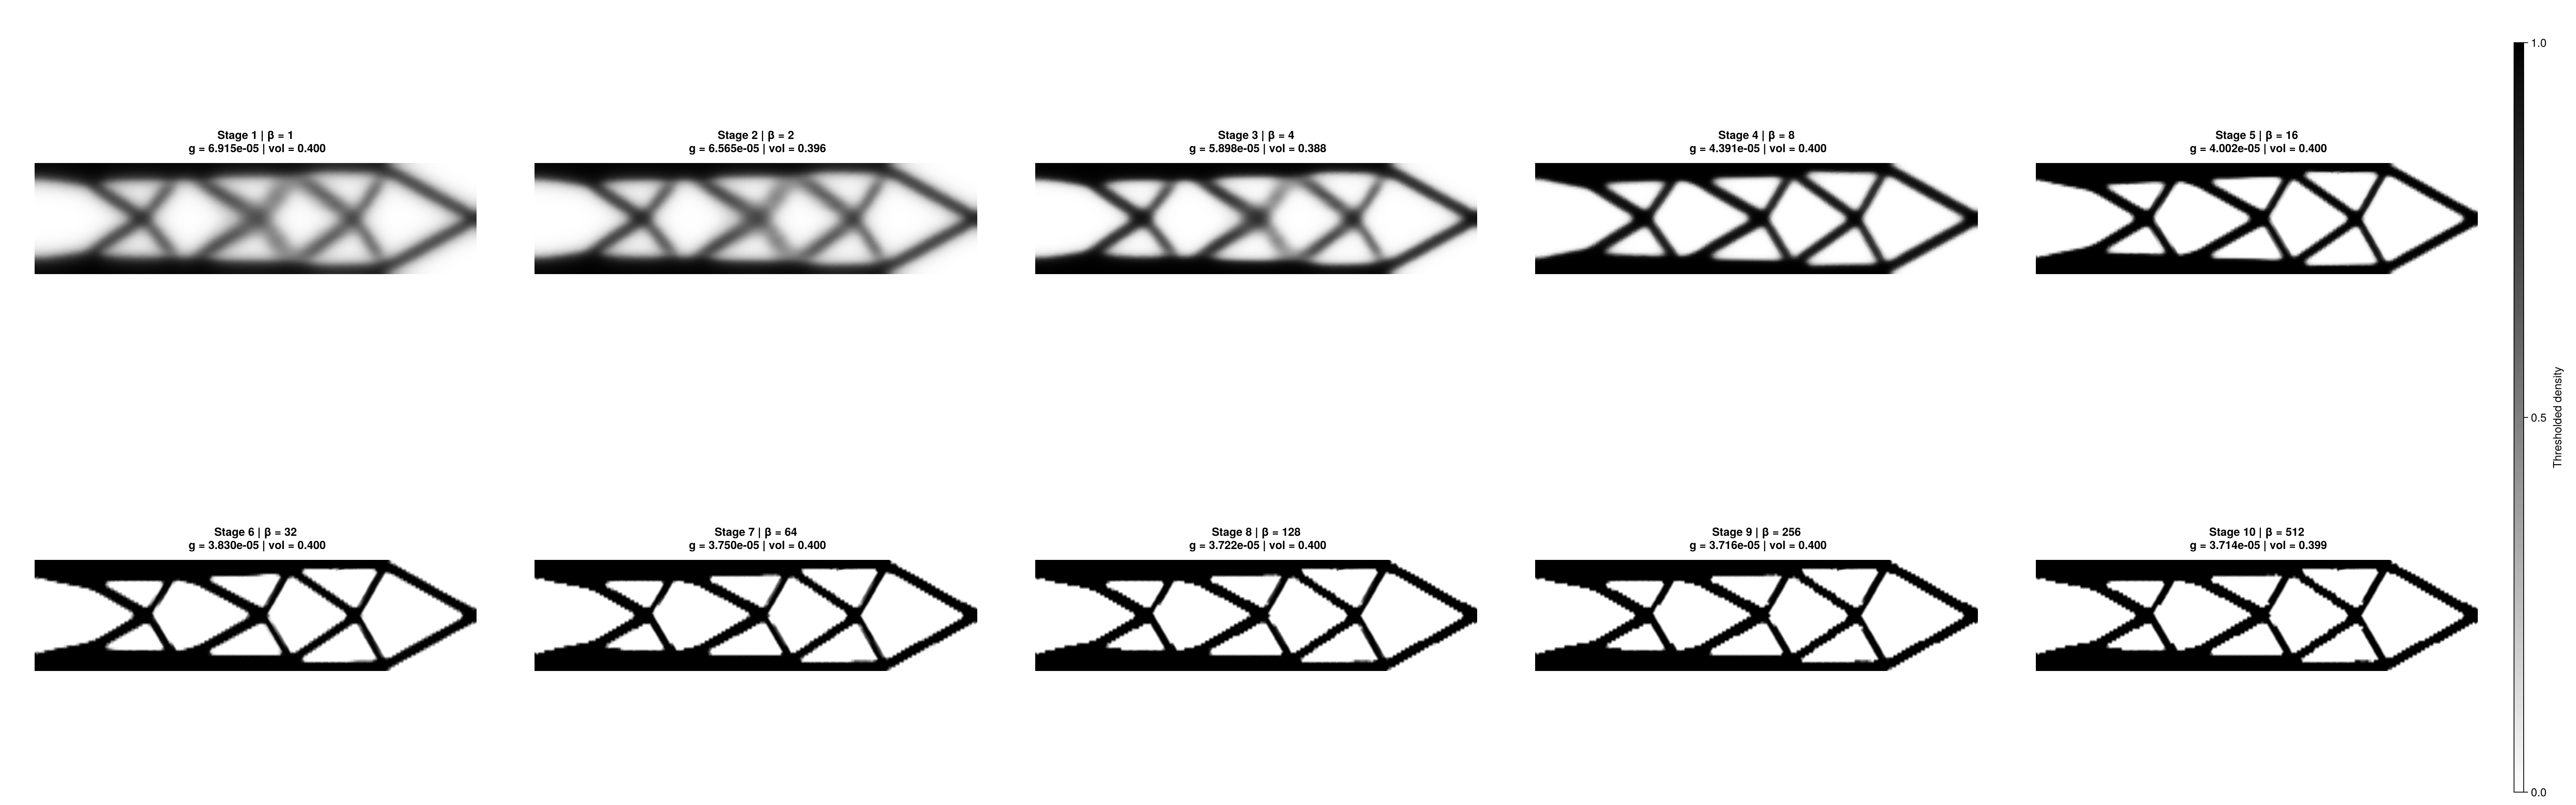

In [27]:
# Plot 1 figure with all checkpoints
fig = plot_checkpoint_shapes(
    "beam_mma";
    r = r,
    η = 0.5,                  # or whatever η you used in that run
    fem_params = fem_params,
    ncols = 5,
    outfile = "beam_mma_checkpoints.png"
)

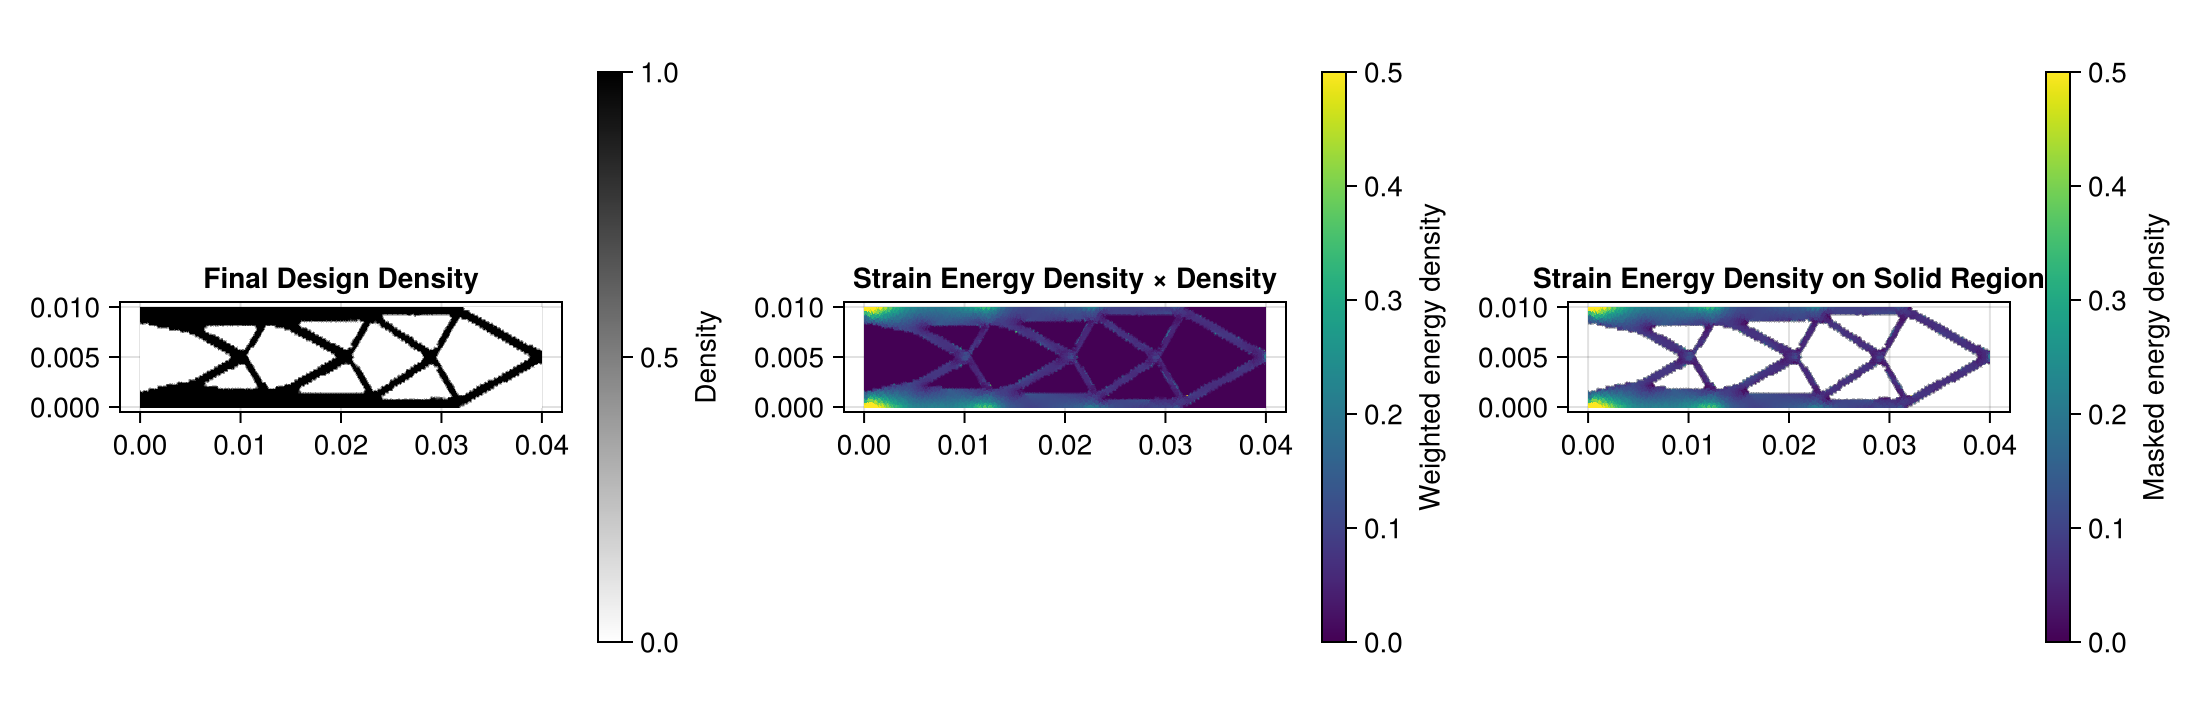

In [28]:
# Plot local strain energy density for the final design
##################### Load Final Design #####################

p0 = deserialize("beam_mma/p_final.jls")

pf_vec = pf_p0(p0; r=r, fem_params=fem_params)
pfh = FEFunction(fem_params.Pf, pf_vec)

β_final = 512.0
η_final = η

pth = (pf -> Threshold(pf; β=β_final, η=η_final)) ∘ pfh

##################### Solve Final Displacement #####################

K_mat = MatrixK(pth; phys_params=phys_params, fem_params=fem_params)

F_vec = assemble_vector(fem_params.V) do v
    ∫(v ⋅ phys_params.traction)fem_params.dΓ_load
end

u_vec = K_mat \ F_vec
uh = FEFunction(fem_params.U, u_vec)

##################### Strain Energy Density #####################

# SIMP Young's modulus field
E_pth = (p -> phys_params.Emin + p^(phys_params.q_simp) * (phys_params.E0 - phys_params.Emin)) ∘ pth

# Stress using density-dependent stiffness
function σ_simp(u, Efield; phys_params)
    poisson = phys_params.ν
    strain_u = ε(u)

    λfield = (Efield * poisson) / ((1.0 + poisson) * (1.0 - 2.0 * poisson))
    μfield = Efield / (2.0 * (1.0 + poisson))

    return λfield * tr(strain_u) * I2 + 2.0 * μfield * strain_u
end

# W(x) = 1/2 ε(u) : σ(u, pth)
W = 0.5 * (ε(uh) ⊙ σ_simp(uh, E_pth; phys_params=phys_params))

# Weighted version: suppresses void regions smoothly
W_weighted = pth * W

# Masked version: blanks out void-like regions
solid_mask = (p -> p > 0.5 ? 1.0 : NaN) ∘ pth
W_masked = solid_mask * W

##################### Plot Density and Strain Energy #####################

fig = Figure(size=(1100, 360))

ax1 = Axis(fig[1, 1], aspect=DataAspect(), title="Final Design Density")
plt1 = plot!(ax1, fem_params.Ω, pth, colormap=:binary, colorrange=(0.0, 1.0))
Colorbar(fig[1, 2], plt1, label="Density")

ax2 = Axis(fig[1, 3], aspect=DataAspect(), title="Strain Energy Density × Density")
plt2 = plot!(ax2, fem_params.Ω, W_weighted, colormap=:viridis, colorrange=(0.0, 0.5))
Colorbar(fig[1, 4], plt2, label="Weighted energy density")

ax3 = Axis(fig[1, 5], aspect=DataAspect(), title="Strain Energy Density on Solid Region")
plt3 = plot!(ax3, fem_params.Ω, W_masked, colormap=:viridis, colorrange=(0.0, 0.5))
Colorbar(fig[1, 6], plt3, label="Masked energy density")

save("beam_mma/final_density_and_strain_energy.png", fig)

fig

In [29]:
println("Full area = ", sum(∫(1.0)dΩ))
println("Design area = ", sum(∫(1.0)dΩ_d))

Full area = 0.0003999999999999747
Design area = 0.0003999999999999747


### Export to Paraview

In [ ]:
# use pth from above
writevtk(
    fem_params.Ω,
    "beam_mma/final_density",
    cellfields = [
        "pth" => pth
    ]
)

(["beam_mma/final_density.vtu"],)

: 